In [15]:
import pandas as pd


# Load the CSV files into pandas DataFrames
train_X_path = 'X_train.csv'
train_y_path = 'y_train.csv'
test_X_path = 'X_test.csv'

train_X = pd.read_csv(train_X_path)
train_y = pd.read_csv(train_y_path)
test_X = pd.read_csv(test_X_path)

# Display the first few rows of each DataFrame to confirm loading
print("X_train DataFrame:")
print(train_X.head())

print("\ny_train DataFrame:")
print(train_y.head())

print("\nX_test DataFrame:")
print(test_X.head())

print(train_X.columns)

X_train DataFrame:
   id  trq_measured       oat       mgt         pa       ias         np  \
0   0        54.100   2.00000  544.5000   212.1408  74.56250   89.18000   
1   1        49.625  24.22231  578.4844  1625.6400  30.35596   99.55273   
2   2        52.000   7.00000  566.1000  1912.9250  65.62500  100.14000   
3   3        62.400   7.25000  560.1000   277.0632  54.81250   90.64000   
4   4        62.900  23.25000  593.7000    53.6448  73.43750   99.91000   

         ng  
0   99.6400  
1   91.3866  
2   90.9600  
3  100.2800  
4   92.1700  

y_train DataFrame:
   id  faulty  trq_margin
0   0       1  -13.717745
1   1       0    1.791863
2   2       1  -13.944871
3   3       0   -0.017281
4   4       0    7.322404

X_test DataFrame:
   id  trq_measured    oat    mgt        pa       ias      np     ng
0   0          76.2  29.50  648.0  303.2760    0.0000   99.83  96.77
1   1          63.3  18.75  595.4  464.8200   96.5625  100.01  93.61
2   2          87.3   2.50  644.4  503.5296 

In [5]:
pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


X_train DataFrame:
   id  trq_measured       oat       mgt         pa       ias         np  \
0   0        54.100   2.00000  544.5000   212.1408  74.56250   89.18000   
1   1        49.625  24.22231  578.4844  1625.6400  30.35596   99.55273   
2   2        52.000   7.00000  566.1000  1912.9250  65.62500  100.14000   
3   3        62.400   7.25000  560.1000   277.0632  54.81250   90.64000   
4   4        62.900  23.25000  593.7000    53.6448  73.43750   99.91000   

         ng  
0   99.6400  
1   91.3866  
2   90.9600  
3  100.2800  
4   92.1700  

y_train DataFrame:
   id  faulty  trq_margin
0   0       1  -13.717745
1   1       0    1.791863
2   2       1  -13.944871
3   3       0   -0.017281
4   4       0    7.322404

X_test DataFrame:
   id  trq_measured    oat    mgt        pa       ias      np     ng
0   0          76.2  29.50  648.0  303.2760    0.0000   99.83  96.77
1   1          63.3  18.75  595.4  464.8200   96.5625  100.01  93.61
2   2          87.3   2.50  644.4  503.5296 

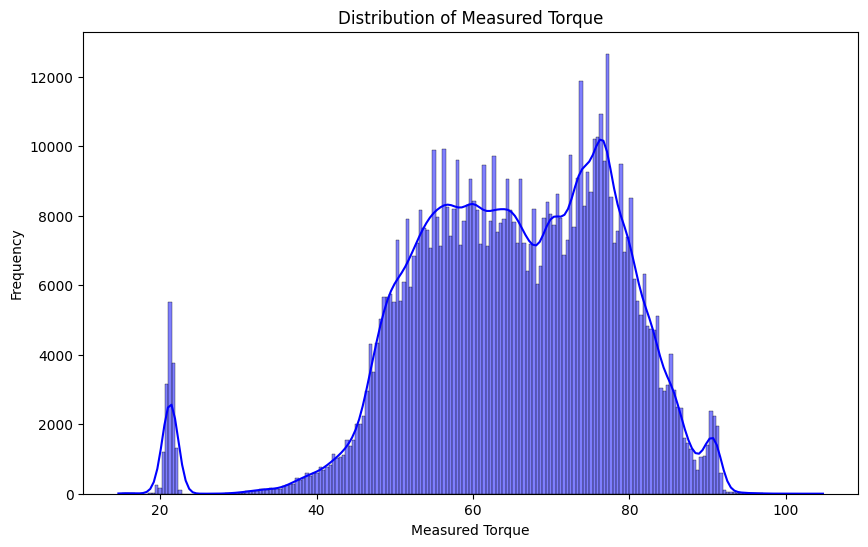

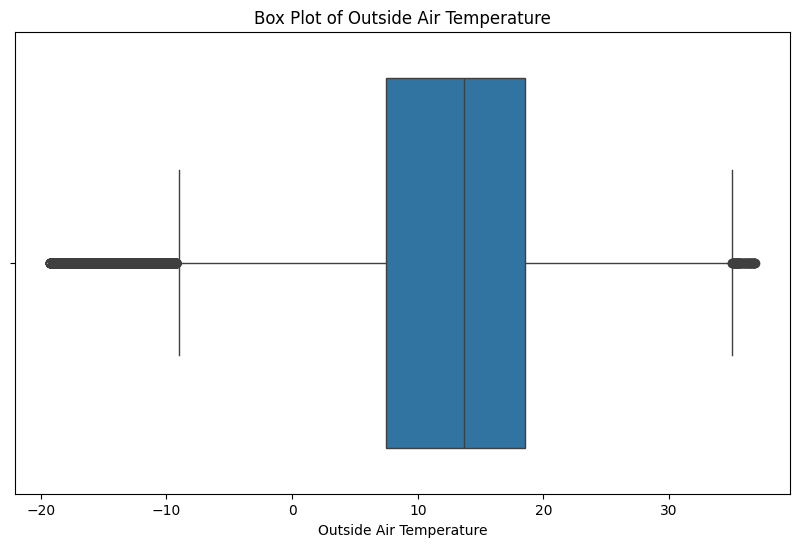

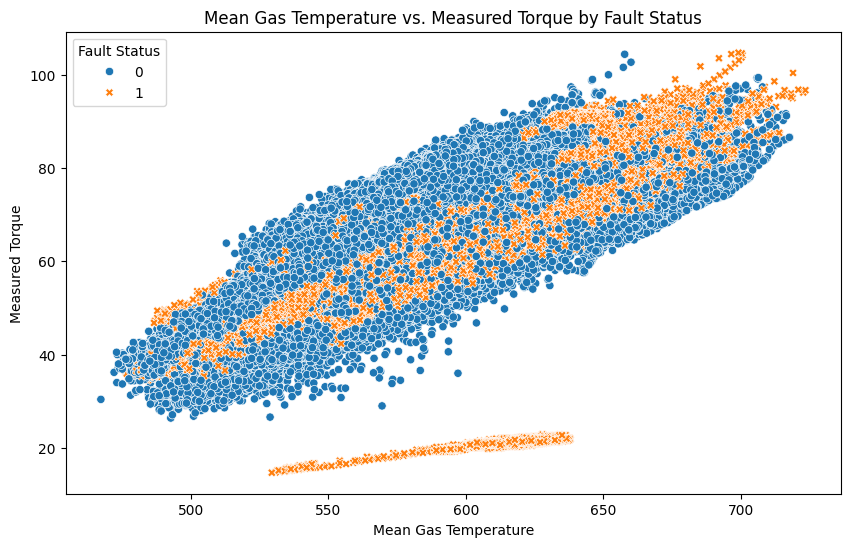

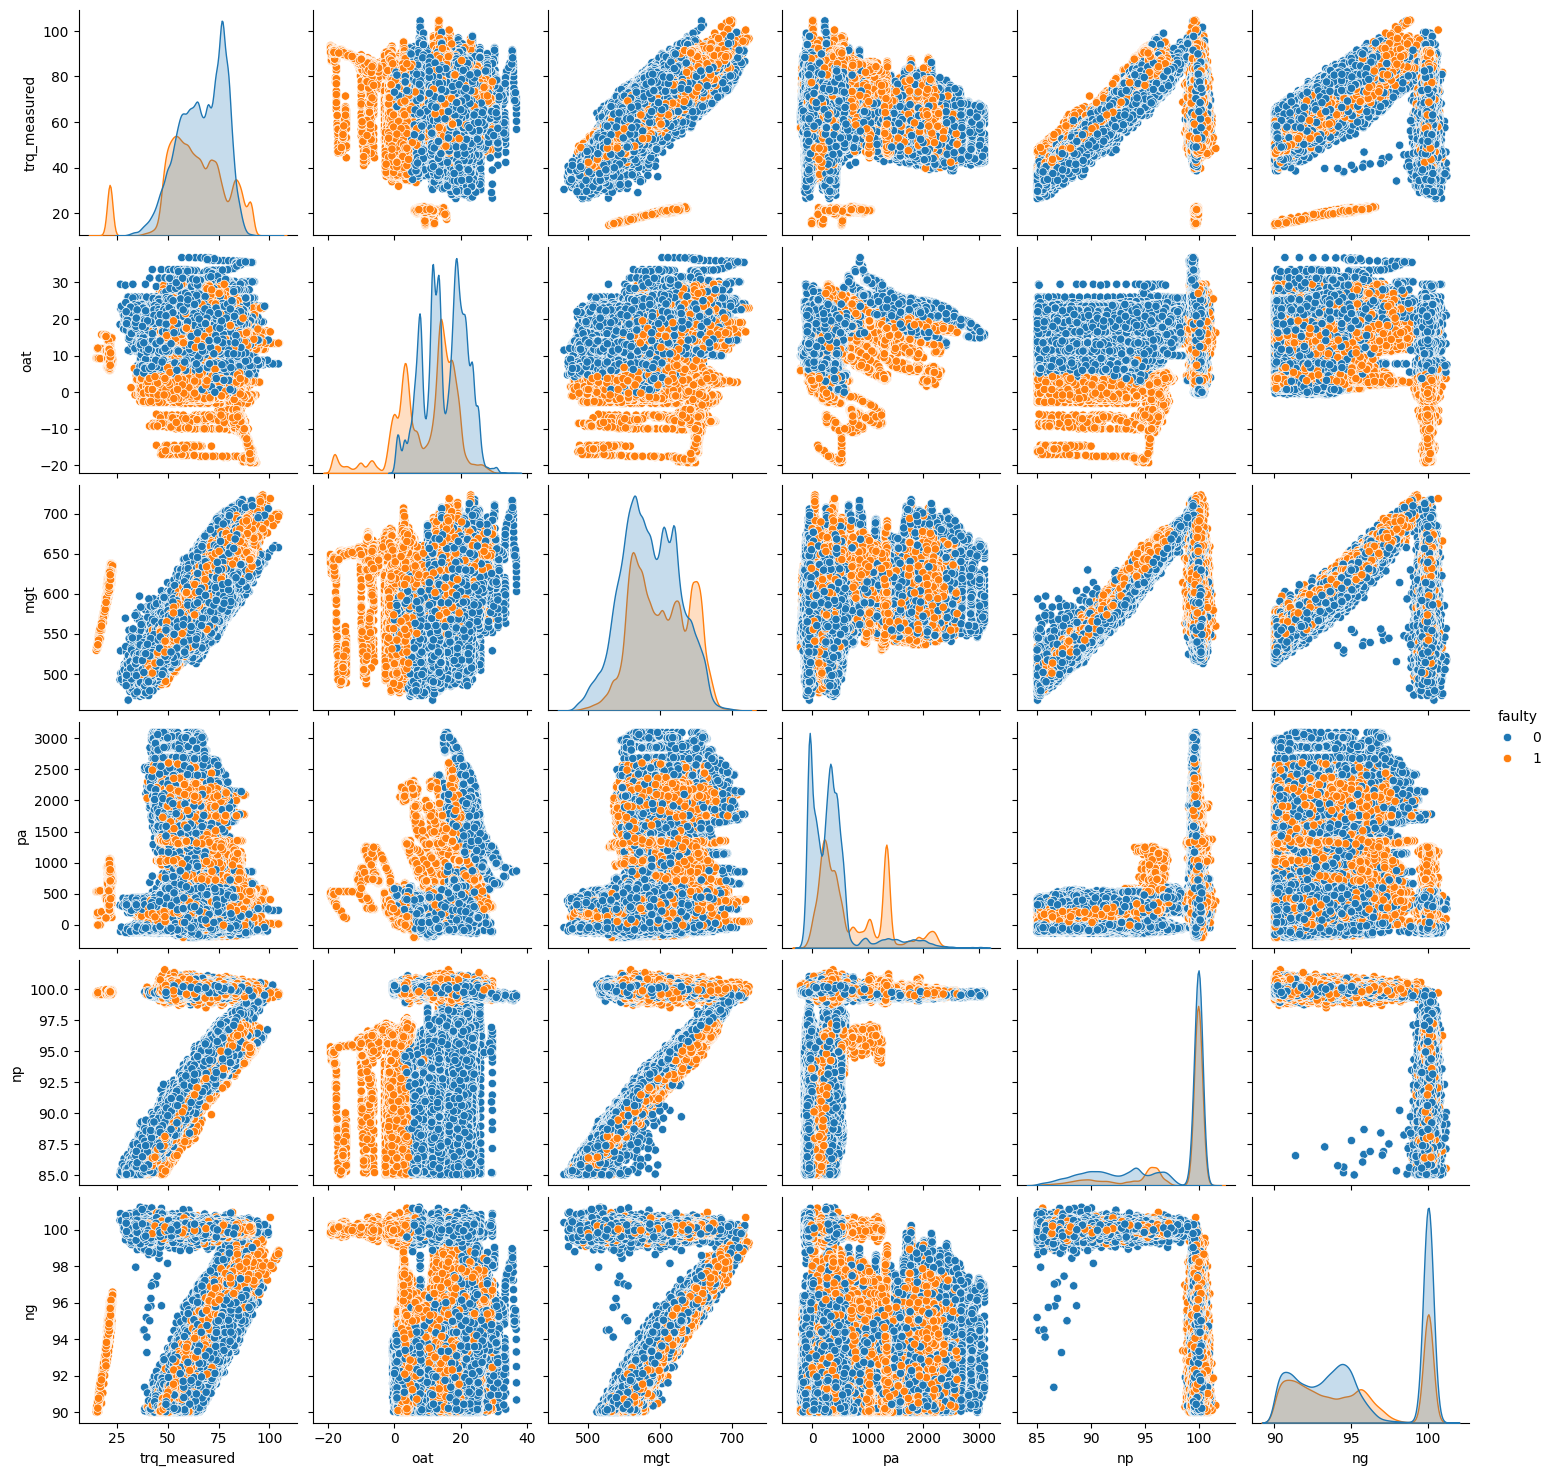

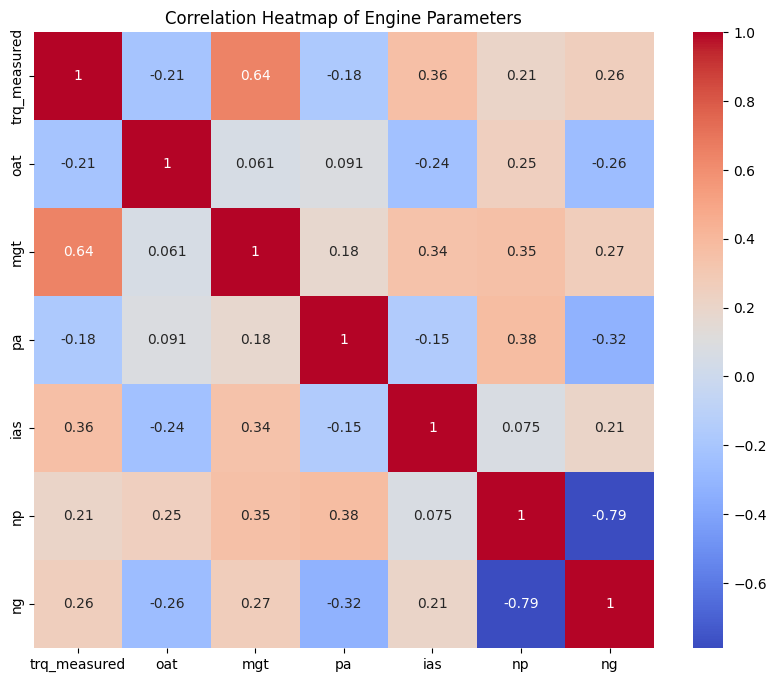

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV files into pandas DataFrames
train_X_path = 'X_train.csv'
train_y_path = 'y_train.csv'
test_X_path = 'X_test.csv'

train_X = pd.read_csv(train_X_path)
train_y = pd.read_csv(train_y_path)
test_X = pd.read_csv(test_X_path)

# Display the first few rows of each DataFrame to confirm loading
print("X_train DataFrame:")
print(train_X.head())
print("\ny_train DataFrame:")
print(train_y.head())
print("\nX_test DataFrame:")
print(test_X.head())

# Merge train_X and train_y for joint visualizations
train_data = pd.merge(train_X, train_y, on='id')

# Visualization 1: Histogram of Measured Torque
plt.figure(figsize=(10, 6))
sns.histplot(train_data['trq_measured'], kde=True, color='blue')
plt.title('Distribution of Measured Torque')
plt.xlabel('Measured Torque')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Box Plot of Outside Air Temperature
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_data['oat'])
plt.title('Box Plot of Outside Air Temperature')
plt.xlabel('Outside Air Temperature')
plt.show()

# Visualization 3: Scatter Plot - Mean Gas Temperature vs. Measured Torque
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mgt', y='trq_measured', data=train_data, hue='faulty', style='faulty')
plt.title('Mean Gas Temperature vs. Measured Torque by Fault Status')
plt.xlabel('Mean Gas Temperature')
plt.ylabel('Measured Torque')
plt.legend(title='Fault Status')
plt.show()

# Visualization 4: Pair Plot for selected variables
sns.pairplot(train_data[['trq_measured', 'oat', 'mgt', 'pa', 'np', 'ng', 'faulty']], hue='faulty')
plt.show()

# Visualization 5: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = train_data[['trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Engine Parameters')
plt.show()


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the CSV files into pandas DataFrames
train_X_path = 'X_train.csv'
train_y_path = 'y_train.csv'
test_X_path = 'X_test.csv'

train_X = pd.read_csv(train_X_path)
train_y = pd.read_csv(train_y_path)
test_X = pd.read_csv(test_X_path)

# Display the first few rows of each DataFrame to confirm loading
print("X_train DataFrame:")
print(train_X.head())
print("\ny_train DataFrame:")
print(train_y.head())
print("\nX_test DataFrame:")
print(test_X.head())

# Check for missing values
print(train_X.isnull().sum())
print(train_y.isnull().sum())
print(test_X.isnull().sum())

# Handling Missing Values: Imputation
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Identifying numerical columns for scaling and categorical for encoding
numerical_cols = train_X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_X.select_dtypes(include=['object']).columns

# Removing Outliers (based on IQR for numerical columns)
Q1 = train_X[numerical_cols].quantile(0.25)
Q3 = train_X[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
train_X = train_X[~((train_X[numerical_cols] < (Q1 - 1.5 * IQR)) | (train_X[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Feature Scaling and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

train_X = pd.DataFrame(preprocessor.fit_transform(train_X))
test_X = pd.DataFrame(preprocessor.transform(test_X))

# Display the processed data
print("Processed X_train DataFrame:")
print(train_X.head())


X_train DataFrame:
   id  trq_measured       oat       mgt         pa       ias         np  \
0   0        54.100   2.00000  544.5000   212.1408  74.56250   89.18000   
1   1        49.625  24.22231  578.4844  1625.6400  30.35596   99.55273   
2   2        52.000   7.00000  566.1000  1912.9250  65.62500  100.14000   
3   3        62.400   7.25000  560.1000   277.0632  54.81250   90.64000   
4   4        62.900  23.25000  593.7000    53.6448  73.43750   99.91000   

         ng  
0   99.6400  
1   91.3866  
2   90.9600  
3  100.2800  
4   92.1700  

y_train DataFrame:
   id  faulty  trq_margin
0   0       1  -13.717745
1   1       0    1.791863
2   2       1  -13.944871
3   3       0   -0.017281
4   4       0    7.322404

X_test DataFrame:
   id  trq_measured    oat    mgt        pa       ias      np     ng
0   0          76.2  29.50  648.0  303.2760    0.0000   99.83  96.77
1   1          63.3  18.75  595.4  464.8200   96.5625  100.01  93.61
2   2          87.3   2.50  644.4  503.5296 

In [12]:
pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 102.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [17]:
print(train_X.columns)
if 'trq_measured' in train_X.columns:
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    train_X['trq_measured'] = pt.fit_transform(train_X[['trq_measured']])
else:
    print("Column 'trq_measured' does not exist in train_X.")

Index(['id', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng'], dtype='object')


In [18]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load Data
train_X = pd.read_csv('X_train.csv')
print("Initial Columns:", train_X.columns)  # Debug: Check initial columns

# Check for missing column
if 'trq_measured' not in train_X.columns:
    raise ValueError("Column 'trq_measured' is missing from train_X.")

# Apply PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)
train_X['trq_measured'] = pt.fit_transform(train_X[['trq_measured']])

# Advanced imputation (if needed)
iter_impute = IterativeImputer(max_iter=10, random_state=0)
train_X = pd.DataFrame(iter_impute.fit_transform(train_X), columns=train_X.columns)

# Further processing...


Initial Columns: Index(['id', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng'], dtype='object')


 #### Binning

In [24]:

# Find the min and max of scaled 'trq_measured' to define bins
min_val = train_X['trq_measured'].min()
max_val = train_X['trq_measured'].max()

# Define bins based on scaled range
bins = [min_val, -0.5, 0.5, max_val]
labels = ["Low", "Medium", "High"]

train_X['binned_trq_measured'] = pd.cut(train_X['trq_measured'], bins=bins, labels=labels)
print(train_X[['trq_measured', 'binned_trq_measured']].head())




   trq_measured binned_trq_measured
0     -0.901947                 Low
1     -1.192240                 Low
2     -1.040861                 Low
3     -0.306258              Medium
4     -0.267977              Medium


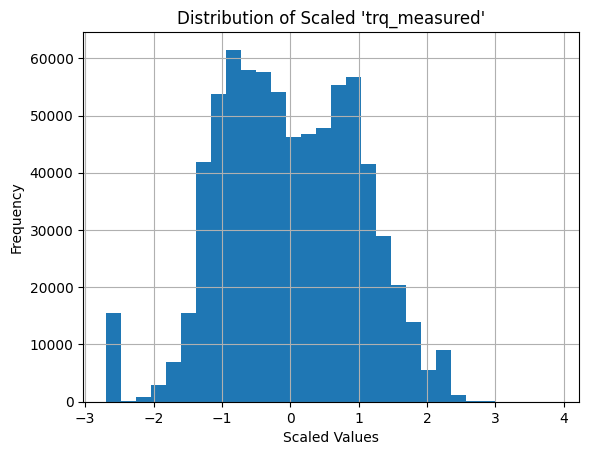

In [25]:
import matplotlib.pyplot as plt

train_X['trq_measured'].hist(bins=30)
plt.title("Distribution of Scaled 'trq_measured'")
plt.xlabel("Scaled Values")
plt.ylabel("Frequency")
plt.show()


In [26]:
correlation = pd.crosstab(train_X['binned_trq_measured'], train_y['faulty'], normalize='index')
print(correlation)


faulty                      0         1
binned_trq_measured                    
Low                  0.502448  0.497552
Medium               0.622727  0.377273
High                 0.669206  0.330794


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the datasets
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Merge train_X and train_y for joint processing
train = pd.merge(train_X, train_y, on='id')

# Drop 'id' column as it's not a feature
train.drop(columns=['id'], inplace=True)
test_X.drop(columns=['id'], inplace=True)

# Separate features and target
X = train.drop(columns=['faulty', 'trq_margin'])
y = train['faulty']

# Advanced Imputation: Iterative Imputer
imputer = IterativeImputer(max_iter=10, random_state=0)
X_imputed = imputer.fit_transform(X)
test_X_imputed = imputer.transform(test_X)

# Scaling: PowerTransformer for normality
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = scaler.fit_transform(X_imputed)
test_X_scaled = scaler.transform(test_X_imputed)

# Feature Construction: Interaction Terms
# Example: Interaction between 'trq_measured' and 'oat'
X_interaction = np.hstack((X_scaled, (X_scaled[:, 0] * X_scaled[:, 1]).reshape(-1, 1)))
test_X_interaction = np.hstack((test_X_scaled, (test_X_scaled[:, 0] * test_X_scaled[:, 1]).reshape(-1, 1)))

# Feature Selection: SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_interaction, y)
test_X_selected = selector.transform(test_X_interaction)

# Dimensionality Reduction: Principal Component Analysis (PCA)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_selected)
test_X_pca = pca.transform(test_X_selected)

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Model Training: RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Validation
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {accuracy:.2f}')

# Predict on Test Set
test_predictions = model.predict(test_X_pca)


Validation Accuracy: 0.96


 #### Correlation Threshold

In [28]:
import pandas as pd
import numpy as np

# Compute correlation matrix
correlation_matrix = pd.DataFrame(X_scaled).corr()

# Define a threshold
threshold = 0.85
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > threshold)]

# Drop highly correlated features
X_reduced_corr = pd.DataFrame(X_scaled).drop(columns=to_drop)
print(f"Features after correlation thresholding: {X_reduced_corr.shape[1]}")


Features after correlation thresholding: 6


###### Univariate Feature Selection **{SelectKBest}**

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select the top 5 features
k_best = SelectKBest(score_func=f_classif, k=5)
X_k_best = k_best.fit_transform(X_scaled, y)

# Get feature scores
feature_scores = k_best.scores_
print(f"Feature Scores: {feature_scores}")


Feature Scores: [  8911.86859584  86678.83239584  26071.34891652 119419.37647514
   8812.3299797   11927.26667285   5948.08714794]


#### Wrapper Methods

##### Recursive Feature Elimination (RFE)

In [30]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Instantiate the model
model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=5)

# Fit RFE
X_rfe = rfe.fit_transform(X_scaled, y)
print(f"Selected Features (RFE): {rfe.support_}")
print(f"Feature Rankings: {rfe.ranking_}")


Selected Features (RFE): [ True  True  True  True False  True False]
Feature Rankings: [1 1 1 1 3 1 2]


##### Sequential Feature Selector

In [31]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
model = LogisticRegression(random_state=42)

# Forward selection
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
X_sfs = sfs.fit_transform(X_scaled, y)
print(f"Features Selected (Forward): {sfs.get_support()}")


Features Selected (Forward): [ True  True  True  True  True False False]


#### Embedded methods

##### a) Feature Importance from Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Train a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_scaled, y)

# Feature importance scores
feature_importances = rf_model.feature_importances_
important_features = np.argsort(feature_importances)[-5:]  # Top 5 features
print(f"Feature Importances: {feature_importances}")


Feature Importances: [0.10519884 0.31813623 0.10419707 0.23421489 0.06738739 0.09308674
 0.07777885]


##### b) L1 Regularization (Lasso)
###### Performs feature selection by penalizing the weights of less important features.

In [33]:
from sklearn.linear_model import LogisticRegression

# L1 regularization
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(X_scaled, y)

# Get the coefficients
lasso_coefficients = lasso.coef_
selected_features = np.where(lasso_coefficients != 0)[1]  # Features with non-zero coefficients
print(f"Selected Features (L1): {selected_features}")


Selected Features (L1): [0 1 2 3 4 5 6]


In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')

# Drop 'id' columns
train_X = train_X.drop(columns=['id'])
train_y = train_y.drop(columns=['id'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)

# Scale the data
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)

# Prepare target variable
y = train_y['faulty']

# Initialize a common model
model = RandomForestClassifier(random_state=42)

# Dictionary to store cross-validation results
cv_results = {}

# 1. SelectKBest (Univariate Selection)
select_kbest = SelectKBest(score_func=f_classif, k=5)
X_kbest = select_kbest.fit_transform(train_X_scaled, y)
cv_results['SelectKBest'] = cross_val_score(model, X_kbest, y, cv=5, scoring='accuracy').mean()

# 2. Recursive Feature Elimination (RFE)
rfe = RFE(estimator=model, n_features_to_select=5)
X_rfe = rfe.fit_transform(train_X_scaled, y)
cv_results['RFE'] = cross_val_score(model, X_rfe, y, cv=5, scoring='accuracy').mean()

# 3. Sequential Feature Selector (SFS - Forward Selection)
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
X_sfs = sfs.fit_transform(train_X_scaled, y)
cv_results['SFS (Forward)'] = cross_val_score(model, X_sfs, y, cv=5, scoring='accuracy').mean()

# 4. Feature Importance (Random Forest)
model.fit(train_X_scaled, y)
importances = model.feature_importances_
important_indices = np.argsort(importances)[-5:]  # Top 5 features
X_rf_importances = train_X_scaled[:, important_indices]
cv_results['Random Forest Importances'] = cross_val_score(model, X_rf_importances, y, cv=5, scoring='accuracy').mean()

# 5. L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(train_X_scaled, y)
lasso_selected_features = np.where(lasso.coef_[0] != 0)[0]
X_lasso = train_X_scaled[:, lasso_selected_features]
cv_results['L1 Regularization (Lasso)'] = cross_val_score(model, X_lasso, y, cv=5, scoring='accuracy').mean()

# 6. Principal Component Analysis (PCA)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(train_X_scaled)
cv_results['PCA'] = cross_val_score(model, X_pca, y, cv=5, scoring='accuracy').mean()

# Display results
for method, score in cv_results.items():
    print(f"{method}: Cross-Validation Accuracy = {score:.4f}")


SelectKBest: Cross-Validation Accuracy = 0.9986
RFE: Cross-Validation Accuracy = 0.9986
SFS (Forward): Cross-Validation Accuracy = 0.9990
Random Forest Importances: Cross-Validation Accuracy = 0.9986
L1 Regularization (Lasso): Cross-Validation Accuracy = 0.9994
PCA: Cross-Validation Accuracy = 0.9925


SelectKBest: Cross-Validation Accuracy = 0.9986
RFE: Cross-Validation Accuracy = 0.9986
SFS (Forward): Cross-Validation Accuracy = 0.9990
Random Forest Importances: Cross-Validation Accuracy = 0.9986
L1 Regularization (Lasso): Cross-Validation Accuracy = 0.9994
PCA: Cross-Validation Accuracy = 0.9925


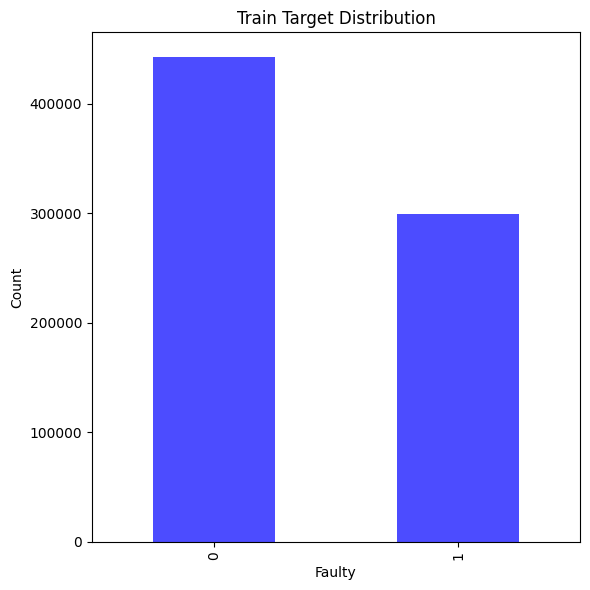

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Drop 'id' columns
train_X = train_X.drop(columns=['id'])
train_y = train_y.drop(columns=['id'])
test_X = test_X.drop(columns=['id'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Scale the data
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Prepare target variable
y = train_y['faulty']

# Initialize a common model
model = RandomForestClassifier(random_state=42)

# Dictionary to store cross-validation results
cv_results = {}

# 1. SelectKBest (Univariate Selection)
select_kbest = SelectKBest(score_func=f_classif, k=5)
X_kbest = select_kbest.fit_transform(train_X_scaled, y)
cv_results['SelectKBest'] = cross_val_score(model, X_kbest, y, cv=5, scoring='accuracy').mean()

# 2. Recursive Feature Elimination (RFE)
rfe = RFE(estimator=model, n_features_to_select=5)
X_rfe = rfe.fit_transform(train_X_scaled, y)
cv_results['RFE'] = cross_val_score(model, X_rfe, y, cv=5, scoring='accuracy').mean()

# 3. Sequential Feature Selector (SFS - Forward Selection)
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
X_sfs = sfs.fit_transform(train_X_scaled, y)
cv_results['SFS (Forward)'] = cross_val_score(model, X_sfs, y, cv=5, scoring='accuracy').mean()

# 4. Feature Importance (Random Forest)
model.fit(train_X_scaled, y)
importances = model.feature_importances_
important_indices = np.argsort(importances)[-5:]  # Top 5 features
X_rf_importances = train_X_scaled[:, important_indices]
cv_results['Random Forest Importances'] = cross_val_score(model, X_rf_importances, y, cv=5, scoring='accuracy').mean()

# 5. L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(train_X_scaled, y)
lasso_selected_features = np.where(lasso.coef_[0] != 0)[0]
X_lasso = train_X_scaled[:, lasso_selected_features]
cv_results['L1 Regularization (Lasso)'] = cross_val_score(model, X_lasso, y, cv=5, scoring='accuracy').mean()

# 6. Principal Component Analysis (PCA)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(train_X_scaled)
cv_results['PCA'] = cross_val_score(model, X_pca, y, cv=5, scoring='accuracy').mean()

# Display results
for method, score in cv_results.items():
    print(f"{method}: Cross-Validation Accuracy = {score:.4f}")

# Plot train and test on target variable
def plot_target_distribution(train_y):
    plt.figure(figsize=(6, 6))
    train_y['faulty'].value_counts().plot(kind='bar', color='blue', alpha=0.7)
    plt.title('Train Target Distribution')
    plt.xlabel('Faulty')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Example usage
plot_target_distribution(train_y)


In [2]:
pip install 'seaborn'

Note: you may need to restart the kernel to use updated packages.


Validation Accuracy: 0.9995


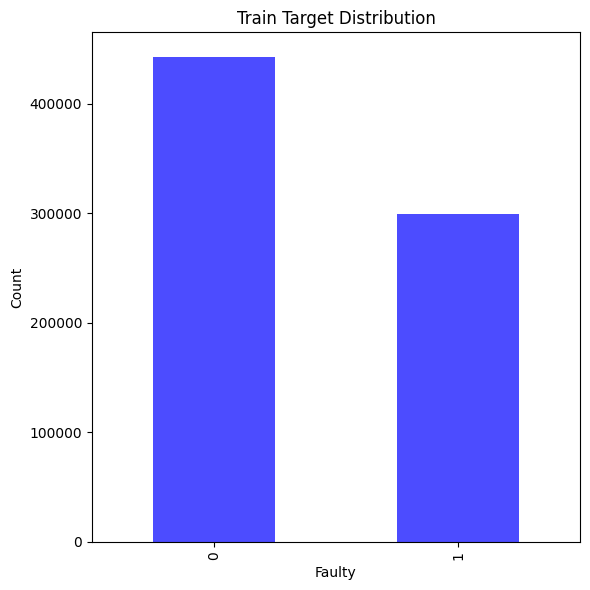

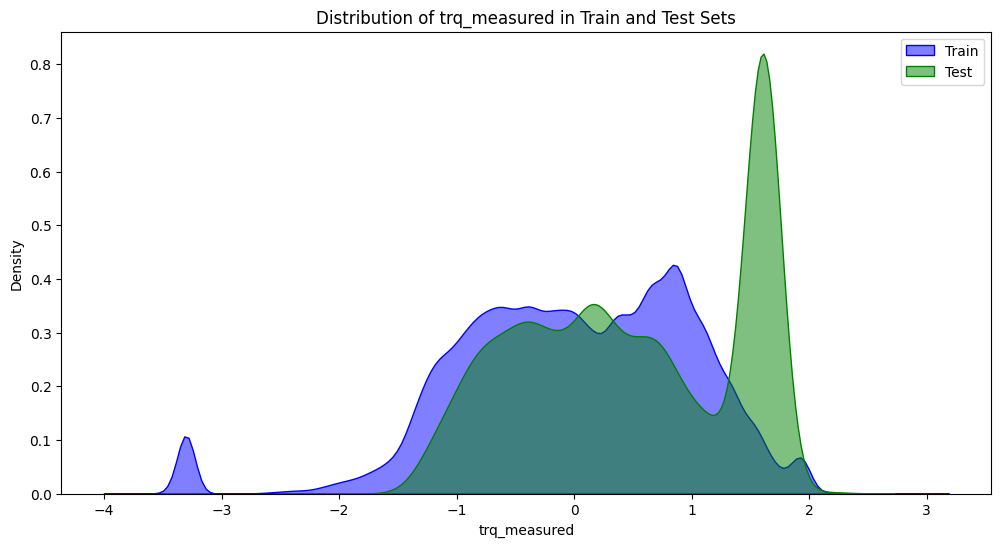

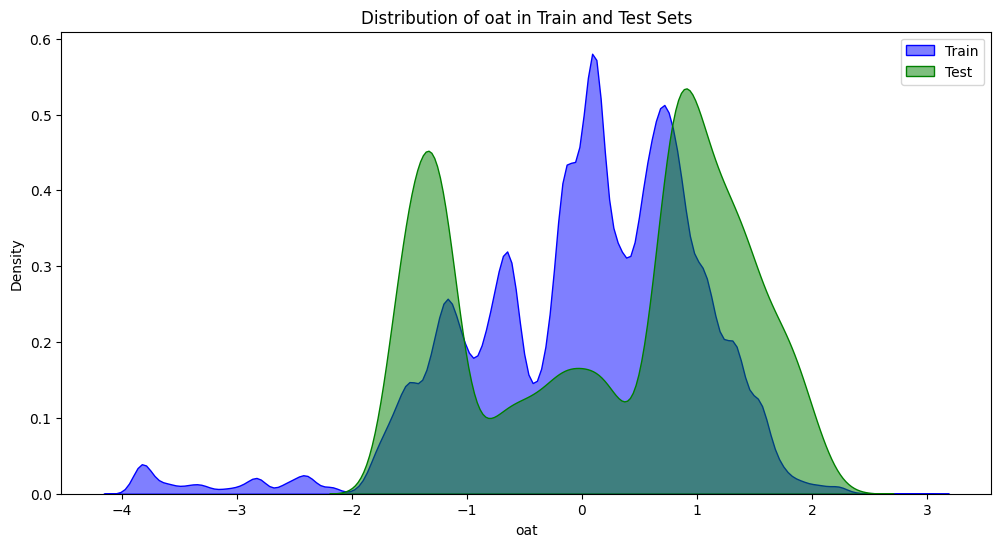

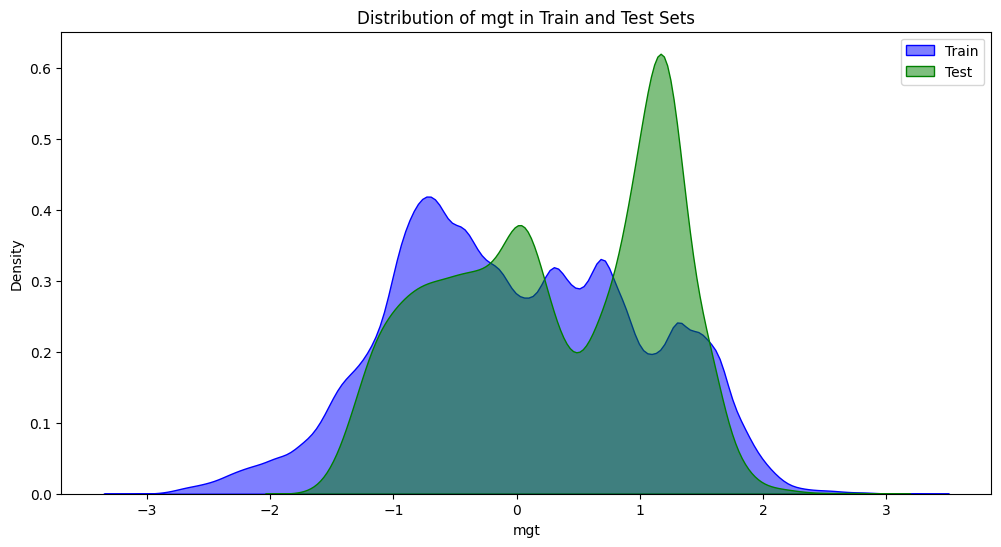

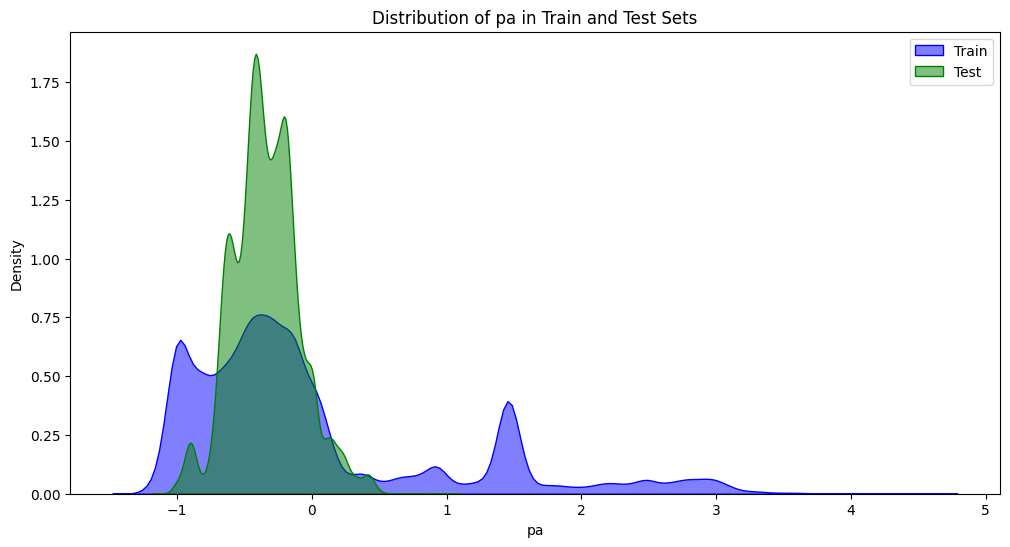

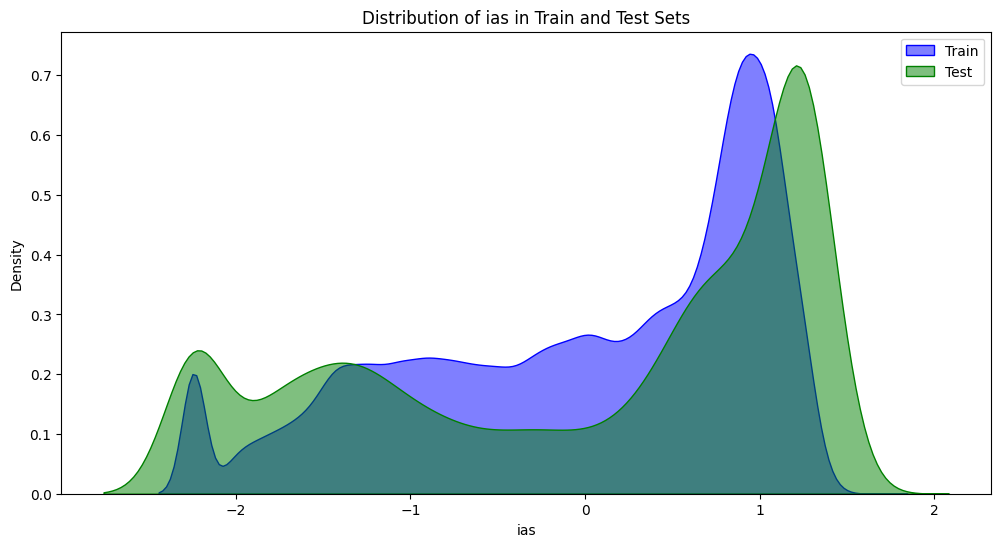

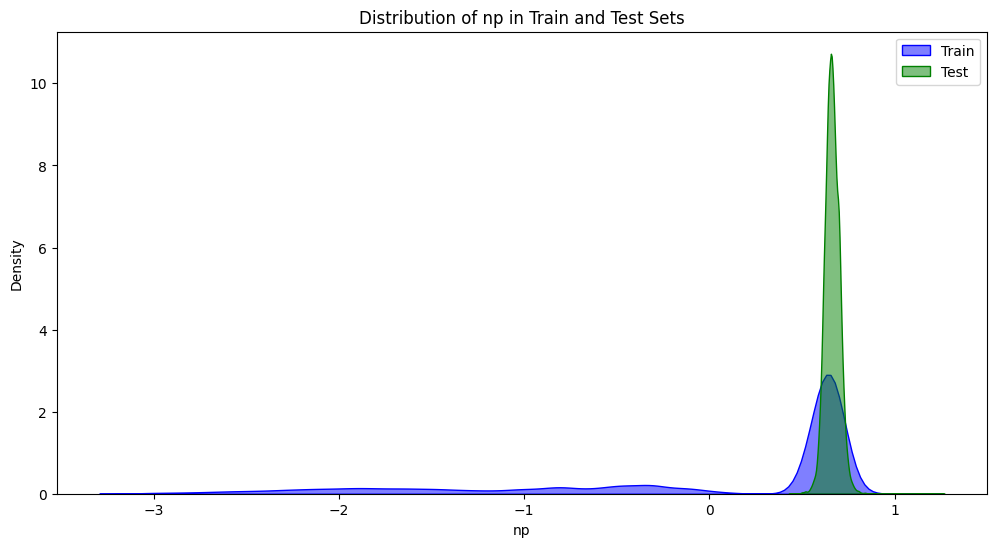

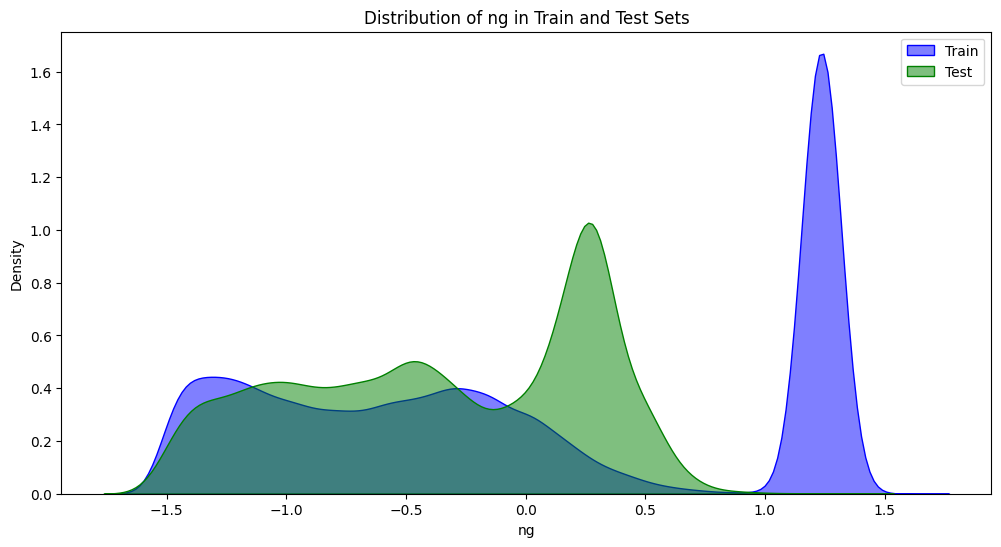

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import norm, cauchy
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

# Load the dataset
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Drop 'id' columns
train_X = train_X.drop(columns=['id'])
train_y = train_y.drop(columns=['id'])
test_X = test_X.drop(columns=['id'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Scale the data
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Prepare target variable
y = train_y['faulty']

# Train-Test Split for Local Validation
X_train, X_val, y_train, y_val = train_test_split(train_X_scaled, y, test_size=0.2, random_state=42)

# Initialize a Random Forest Model with Calibration
model = RandomForestClassifier(random_state=42)
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

# Generate Predictions with Confidence
def predict_with_confidence(model, X):
    probs = model.predict_proba(X)
    confidence = np.max(probs, axis=1)  # Confidence is the probability of the predicted class
    predictions = np.argmax(probs, axis=1)
    return predictions, confidence

# Generate Submission File

def generate_submission(test_X, model, filename="submission.jso"):
    predictions, confidences = predict_with_confidence(model, test_X)
    submission = {}
    for i, (pred, conf) in enumerate(zip(predictions, confidences)):
        pdf = norm if pred == 0 else cauchy  # Example with Normal and Cauchy PDFs
        submission[i] = {
            "class": int(pred),
            "class_conf": float(conf),
            "pdf_type": "norm" if pred == 0 else "cauchy",
            "pdf_args": {"loc": float(pred), "scale": 0.1},
        }
    with open(filename, "w") as f:
        json.dump(submission, f)

# Evaluate on Validation Set
val_predictions, val_confidences = predict_with_confidence(calibrated_model, X_val)
validation_accuracy = np.mean(val_predictions == y_val)
print(f"Validation Accuracy: {validation_accuracy:.4f}")

# Generate Final Submission File
generate_submission(test_X_scaled, calibrated_model, filename="submission.jso")

# Plot train and test on target variable
def plot_target_distribution(train_y):
    plt.figure(figsize=(6, 6))
    train_y['faulty'].value_counts().plot(kind='bar', color='blue', alpha=0.7)
    plt.title('Train Target Distribution')
    plt.xlabel('Faulty')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Visualize Data Distributions
def visualize_data_distributions(train_X, test_X, feature_names):
    for feature in feature_names:
        plt.figure(figsize=(12, 6))
        sns.kdeplot(train_X[feature], label='Train', fill=True, color='blue', alpha=0.5)
        sns.kdeplot(test_X[feature], label='Test', fill=True, color='green', alpha=0.5)
        plt.title(f'Distribution of {feature} in Train and Test Sets')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        plt.show()

# Example usage
plot_target_distribution(train_y)
visualize_data_distributions(pd.DataFrame(train_X_scaled, columns=train_X.columns), pd.DataFrame(test_X_scaled, columns=test_X.columns), train_X.columns)


Linear Regression - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00
Random Forest Regressor - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00


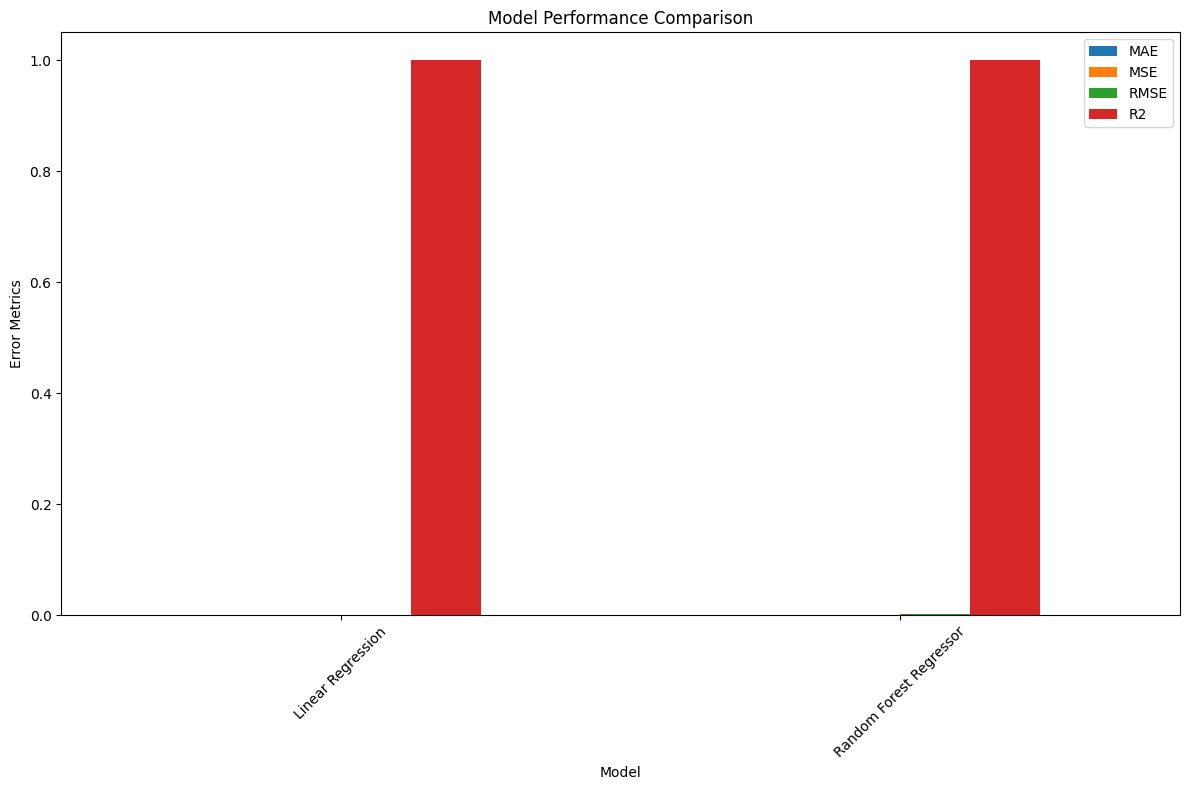

Test Sample 1: Predicted RUL = 31.68
Test Sample 2: Predicted RUL = 46.00
Test Sample 3: Predicted RUL = 19.35
Test Sample 4: Predicted RUL = 21.46
Test Sample 5: Predicted RUL = 35.12
Test Sample 6: Predicted RUL = 21.69
Test Sample 7: Predicted RUL = 49.45
Test Sample 8: Predicted RUL = 50.67
Test Sample 9: Predicted RUL = 33.46
Test Sample 10: Predicted RUL = 28.02


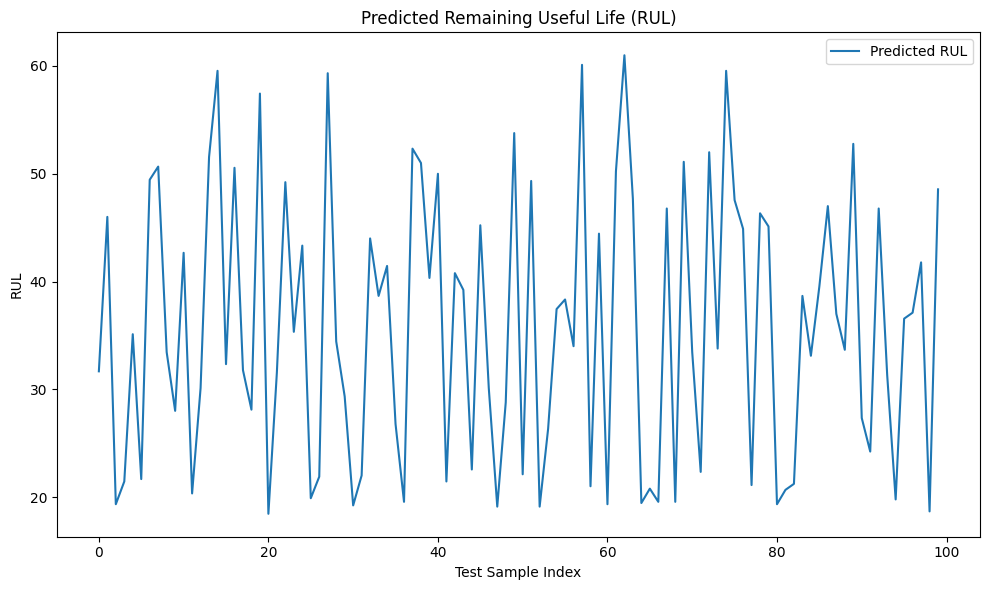

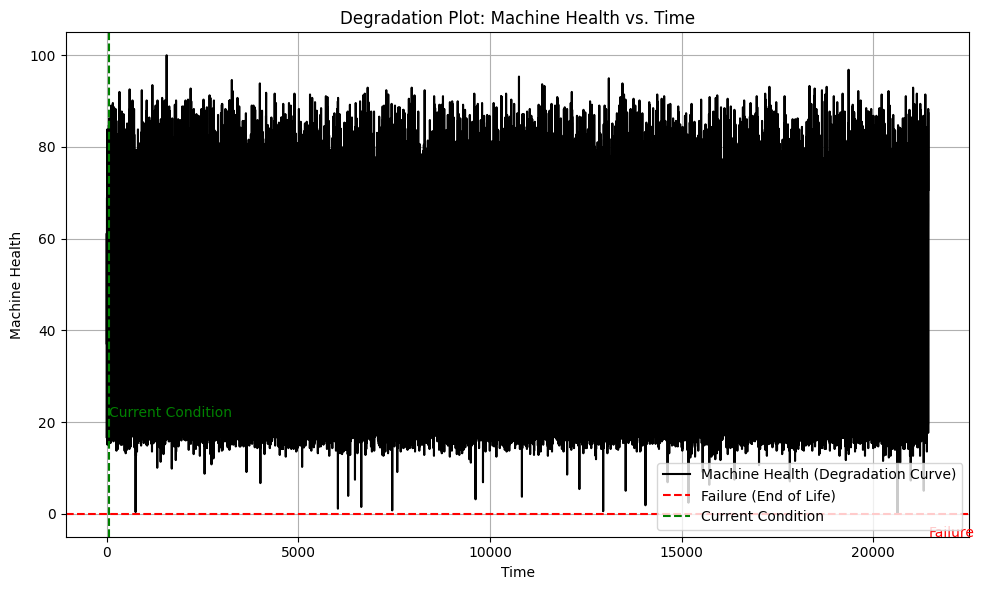

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Drop 'id' columns
train_X = train_X.drop(columns=['id'])
train_y = train_y.drop(columns=['id'])
test_X = test_X.drop(columns=['id'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Scale the data
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Prepare target variable for RUL
train_y_rul = train_y['trq_margin']  # Assuming 'trq_margin' corresponds to RUL

# 5. L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(train_X_scaled, train_y['faulty'])
lasso_selected_features = np.where(lasso.coef_[0] != 0)[0]
X_lasso = train_X_scaled[:, lasso_selected_features]
X_test_lasso = test_X_scaled[:, lasso_selected_features]

# Simulate "current_life" based on the best feature from Lasso
best_feature_index = lasso_selected_features[0]  # Assume the first feature as the most important
train_X['current_life'] = np.interp(train_X.iloc[:, best_feature_index],
                                    (train_X.iloc[:, best_feature_index].min(), train_X.iloc[:, best_feature_index].max()),
                                    (0, 100))
test_X['current_life'] = np.interp(test_X.iloc[:, best_feature_index],
                                   (test_X.iloc[:, best_feature_index].min(), test_X.iloc[:, best_feature_index].max()),
                                   (0, 100))

# Calculate RUL as max_life - current_life
max_life = 100  # Define maximum life as 100 cycles
train_X['RUL'] = max_life - train_X['current_life']
test_X['RUL'] = max_life - test_X['current_life']
train_y_rul = train_X['RUL']

# Train-Test Split for Evaluation
X_train, X_val, y_train, y_val = train_test_split(X_lasso, train_y_rul, test_size=0.2, random_state=42)

# Dictionary to store model performance
model_performance = {}

# Function to evaluate models
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, predictions)
    model_performance[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# Train and evaluate models
# Linear Regression
evaluate_model('Linear Regression', LinearRegression(), X_train, y_train, X_val, y_val)

# Random Forest Regressor
evaluate_model('Random Forest Regressor', RandomForestRegressor(random_state=42), X_train, y_train, X_val, y_val)

# Visualize model comparison
performance_df = pd.DataFrame(model_performance).T
performance_df.plot(kind='bar', figsize=(12, 8))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Error Metrics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Predict RUL on test set using the best-performing model (Random Forest Regressor)
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_lasso, train_y_rul)
test_rul_predictions = best_model.predict(X_test_lasso)

# Display first few RUL predictions
for i, pred in enumerate(test_rul_predictions[:10]):
    print(f"Test Sample {i + 1}: Predicted RUL = {pred:.2f}")

# Visualize the RUL Predictions
plt.figure(figsize=(10, 6))
plt.plot(test_rul_predictions[:100], label='Predicted RUL')
plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.tight_layout()
plt.show()

# Visualizing Machine Health vs. Time (Degradation Plot)
plt.figure(figsize=(10, 6))

# Simulated time (index) and degradation curve for the test set
time = np.arange(len(test_X))
machine_health = max_life - test_X['current_life']  # Simulate machine health as a degradation curve

plt.plot(time, machine_health, color='black', label='Machine Health (Degradation Curve)')
plt.axhline(y=0, color='red', linestyle='--', label='Failure (End of Life)')
plt.axvline(x=50, color='green', linestyle='--', label='Current Condition')
plt.text(50, machine_health[50], 'Current Condition', color='green', fontsize=10, ha='left')
plt.text(len(test_X) - 1, -5, 'Failure', color='red', fontsize=10, ha='left')

# Adding labels and legend
plt.title('Degradation Plot: Machine Health vs. Time')
plt.xlabel('Time')
plt.ylabel('Machine Health')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Linear Regression - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00
Random Forest Regressor - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00


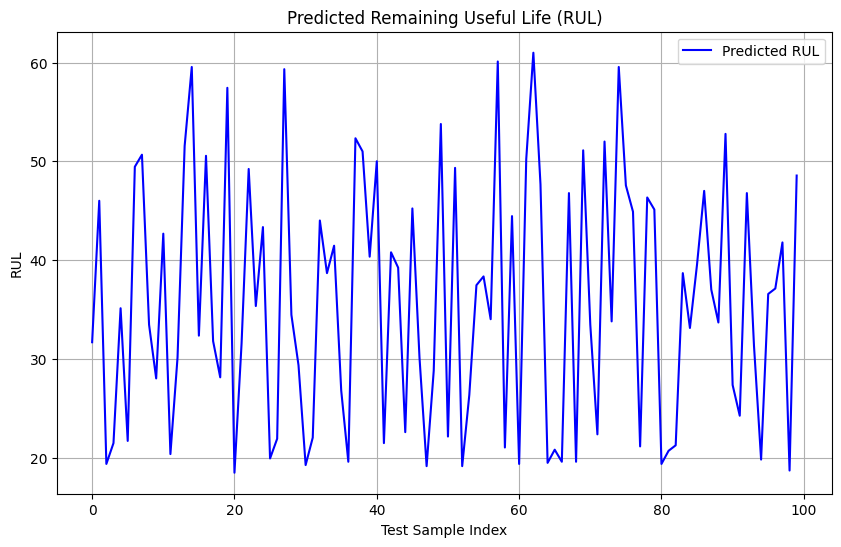

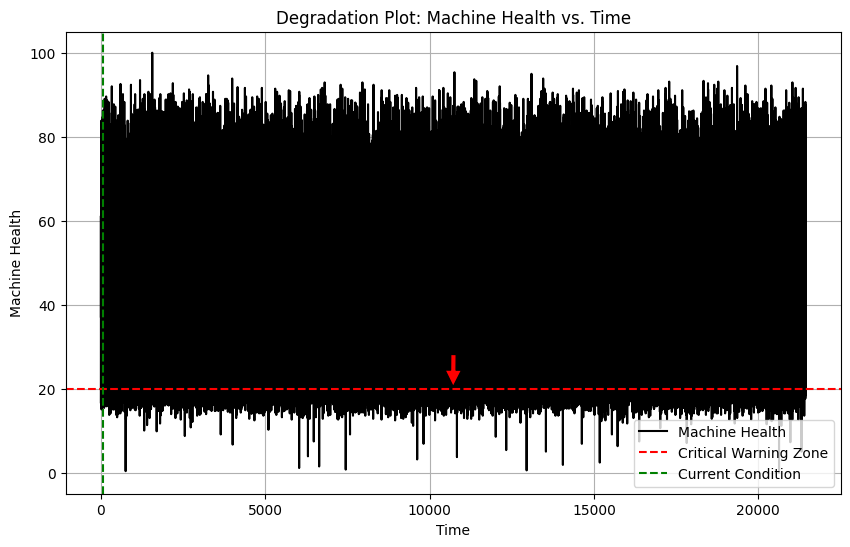

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import necessary machine learning classes and functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the datasets
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Remove 'id' columns which are typically not used for modeling
train_X.drop(columns=['id'], inplace=True)
train_y.drop(columns=['id'], inplace=True)
test_X.drop(columns=['id'], inplace=True)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Assuming 'trq_margin' in train_y represents Remaining Useful Life (RUL)
train_y_rul = train_y['trq_margin']

# L1 Regularization with Logistic Regression for feature selection
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(train_X_scaled, train_y['faulty'])  # Assuming 'faulty' is a binary classification target
lasso_selected_features = np.where(lasso.coef_[0] != 0)[0]  # Indices of selected features
X_lasso = train_X_scaled[:, lasso_selected_features]
X_test_lasso = test_X_scaled[:, lasso_selected_features]

# Linear transformation of a selected feature to simulate 'current life' percentage
best_feature_index = lasso_selected_features[0]  # Assume first selected feature as most important
train_X['current_life'] = np.interp(train_X.iloc[:, best_feature_index],
                                    (train_X.iloc[:, best_feature_index].min(), train_X.iloc[:, best_feature_index].max()),
                                    (0, 100))
test_X['current_life'] = np.interp(test_X.iloc[:, best_feature_index],
                                   (test_X.iloc[:, best_feature_index].min(), test_X.iloc[:, best_feature_index].max()),
                                   (0, 100))

# Calculate RUL based on current life and a defined maximum life
max_life = 100  # Maximum life in cycles
train_X['RUL'] = max_life - train_X['current_life']
test_X['RUL'] = max_life - test_X['current_life']
train_y_rul = train_X['RUL']  # Updated RUL based on current life calculation

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_lasso, train_y_rul, test_size=0.2, random_state=42)

# Function to evaluate and compare model performance
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, predictions)
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# Evaluate Linear Regression and Random Forest models
evaluate_model('Linear Regression', LinearRegression(), X_train, y_train, X_val, y_val)
evaluate_model('Random Forest Regressor', RandomForestRegressor(random_state=42), X_train, y_train, X_val, y_val)

# Predict RUL on the test set using the best-performing model (Random Forest)
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_lasso, train_y_rul)
test_rul_predictions = best_model.predict(X_test_lasso)

# Plot the predicted Remaining Useful Life for the first 100 test samples
plt.figure(figsize=(10, 6))
plt.plot(test_rul_predictions[:100], label='Predicted RUL', color='blue')
plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

# Detailed Degradation Plot with annotations
plt.figure(figsize=(10, 6))
time = np.arange(len(test_X))
machine_health = max_life - test_X['current_life']
plt.plot(time, machine_health, color='black', label='Machine Health')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Warning Zone')
plt.axvline(x=50, color='green', linestyle='--', label='Current Condition')
plt.annotate('Health drops below 20%', xy=(len(time)//2, 20), xytext=(len(time)//2+10, 30),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.title('Degradation Plot: Machine Health vs. Time')
plt.xlabel('Time')
plt.ylabel('Machine Health')
plt.legend()
plt.grid(True)
plt.show()


GENERATED WITH RANDOM TIME STEPS.

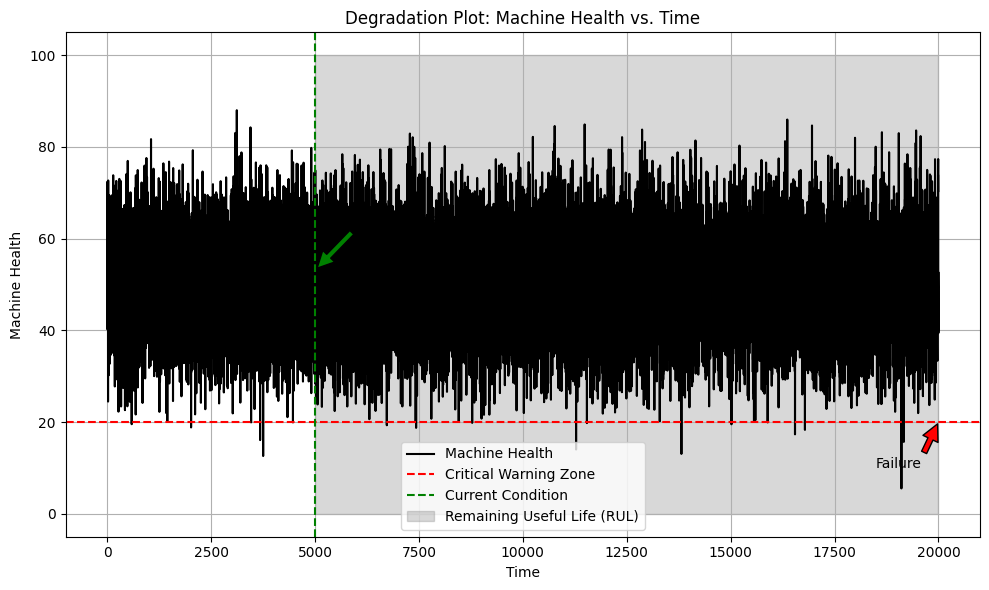

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Example data simulating machine health over time
time = np.arange(0, 20000)  # Time steps
np.random.seed(0)  # For consistent random output
machine_health = np.random.normal(loc=50, scale=10, size=time.shape)  # Simulate machine health values

# Parameters
current_time_index = 5000  # Index for current time
current_health = machine_health[current_time_index]  # Current health at current_time_index
critical_health_threshold = 20  # Health level considered critical

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time, machine_health, label='Machine Health', color='black')
plt.axhline(y=critical_health_threshold, color='red', linestyle='--', label='Critical Warning Zone')
plt.axvline(x=time[current_time_index], color='green', linestyle='--', label='Current Condition')

# Shading RUL area
plt.fill_betweenx(y=[0, 100], x1=time[current_time_index], x2=time[-1], color='gray', alpha=0.3, label='Remaining Useful Life (RUL)')

# Annotations
plt.annotate(f'Current Health: {current_health:.2f}', xy=(time[current_time_index], current_health),
             xytext=(time[current_time_index] + 1000, current_health + 10),
             arrowprops=dict(facecolor='green', shrink=0.05))
plt.annotate('Failure', xy=(time[-1], critical_health_threshold), xytext=(time[-1] - 1500, critical_health_threshold - 10),
             arrowprops=dict(facecolor='red', shrink=0.05))

# Adding labels and legend
plt.title('Degradation Plot: Machine Health vs. Time')
plt.xlabel('Time')
plt.ylabel('Machine Health')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Linear Regression - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00
Random Forest Regressor - MAE: 0.00, MSE: 0.00, RMSE: 0.00, R2: 1.00
Linear Regression - Cross-Validation R² Scores: [1. 1. 1. 1. 1.]
Average R²: 1.00
Random Forest Regressor - Cross-Validation R² Scores: [0.99999992 0.99999995 0.99999992 0.99999996 0.99999994]
Average R²: 1.00


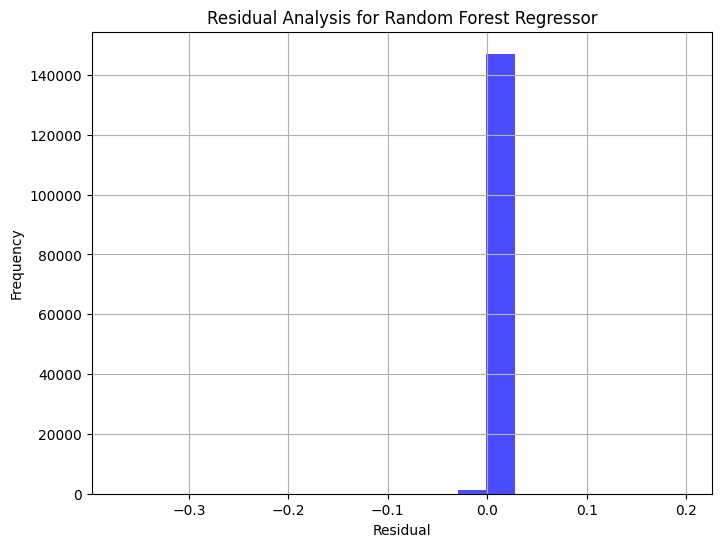

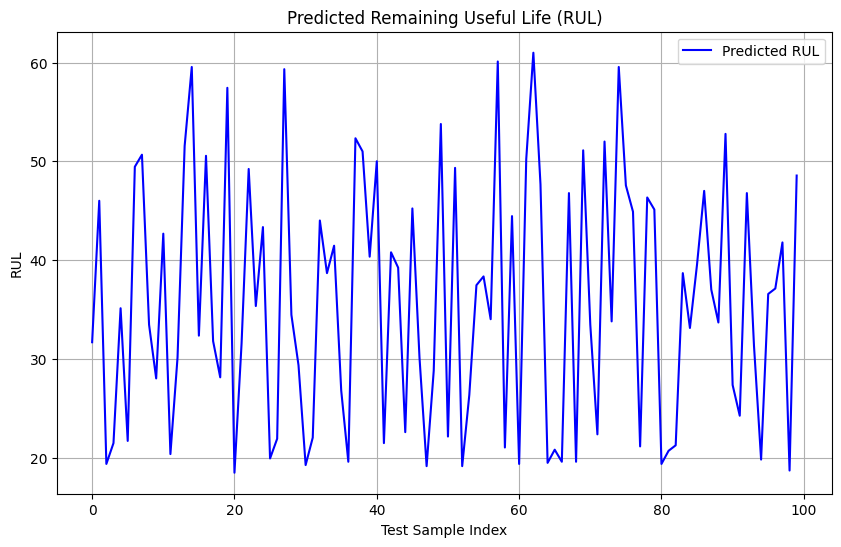

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import necessary machine learning classes and functions
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the datasets
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Remove 'id' columns which are typically not used for modeling
train_X.drop(columns=['id'], inplace=True)
train_y.drop(columns=['id'], inplace=True)
test_X.drop(columns=['id'], inplace=True)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Assuming 'trq_margin' in train_y represents Remaining Useful Life (RUL)
train_y_rul = train_y['trq_margin']

# L1 Regularization with Logistic Regression for feature selection
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
lasso.fit(train_X_scaled, train_y['faulty'])  # Assuming 'faulty' is a binary classification target
lasso_selected_features = np.where(lasso.coef_[0] != 0)[0]  # Indices of selected features
X_lasso = train_X_scaled[:, lasso_selected_features]
X_test_lasso = test_X_scaled[:, lasso_selected_features]

# Linear transformation of a selected feature to simulate 'current life' percentage
best_feature_index = lasso_selected_features[0]  # Assume first selected feature as most important
train_X['current_life'] = np.interp(train_X.iloc[:, best_feature_index],
                                    (train_X.iloc[:, best_feature_index].min(), train_X.iloc[:, best_feature_index].max()),
                                    (0, 100))
test_X['current_life'] = np.interp(test_X.iloc[:, best_feature_index],
                                   (test_X.iloc[:, best_feature_index].min(), test_X.iloc[:, best_feature_index].max()),
                                   (0, 100))

# Calculate RUL based on current life and a defined maximum life
max_life = 100  # Maximum life in cycles
train_X['RUL'] = max_life - train_X['current_life']
test_X['RUL'] = max_life - test_X['current_life']
train_y_rul = train_X['RUL']  # Updated RUL based on current life calculation

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_lasso, train_y_rul, test_size=0.2, random_state=42)

# Function to evaluate model performance
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, predictions)
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
    return model

# Evaluate Linear Regression and Random Forest models
lr_model = evaluate_model('Linear Regression', LinearRegression(), X_train, y_train, X_val, y_val)
rf_model = evaluate_model('Random Forest Regressor', RandomForestRegressor(random_state=42), X_train, y_train, X_val, y_val)

# Cross-validation scores for robustness
def cross_validate_model(name, model, X, y):
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{name} - Cross-Validation R² Scores: {cv_scores}")
    print(f"Average R²: {cv_scores.mean():.2f}")

cross_validate_model('Linear Regression', LinearRegression(), X_lasso, train_y_rul)
cross_validate_model('Random Forest Regressor', RandomForestRegressor(random_state=42), X_lasso, train_y_rul)

# Residual Analysis
y_pred_val = rf_model.predict(X_val)
residuals = y_val - y_pred_val
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, color='blue', alpha=0.7)
plt.title("Residual Analysis for Random Forest Regressor")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Predict RUL on the test set using the best-performing model
test_rul_predictions = rf_model.predict(X_test_lasso)

# Plot the predicted Remaining Useful Life for the first 100 test samples
plt.figure(figsize=(10, 6))
plt.plot(test_rul_predictions[:100], label='Predicted RUL', color='blue')
plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()


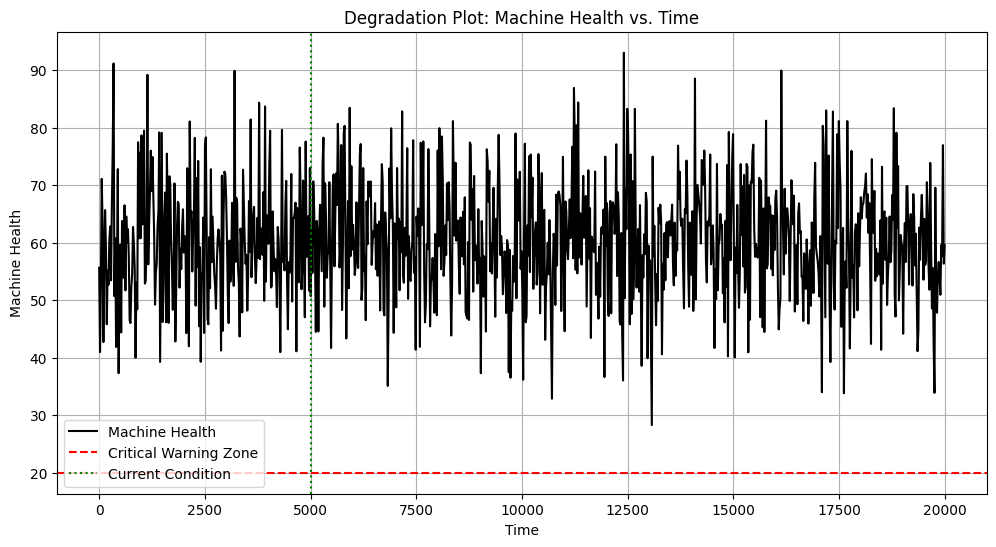

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
time = np.linspace(0, 20000, 1000)
health = np.random.normal(60, 10, len(time))

plt.figure(figsize=(12, 6))
plt.plot(time, health, color='black', label='Machine Health')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Warning Zone')
plt.axvline(x=5000, color='green', linestyle=':', label='Current Condition')

plt.fill_between(time, health, 100, where=(health < 20), color='red', alpha=0.3)
plt.title('Degradation Plot: Machine Health vs. Time')
plt.xlabel('Time')
plt.ylabel('Machine Health')
plt.legend()
plt.grid(True)

plt.show()

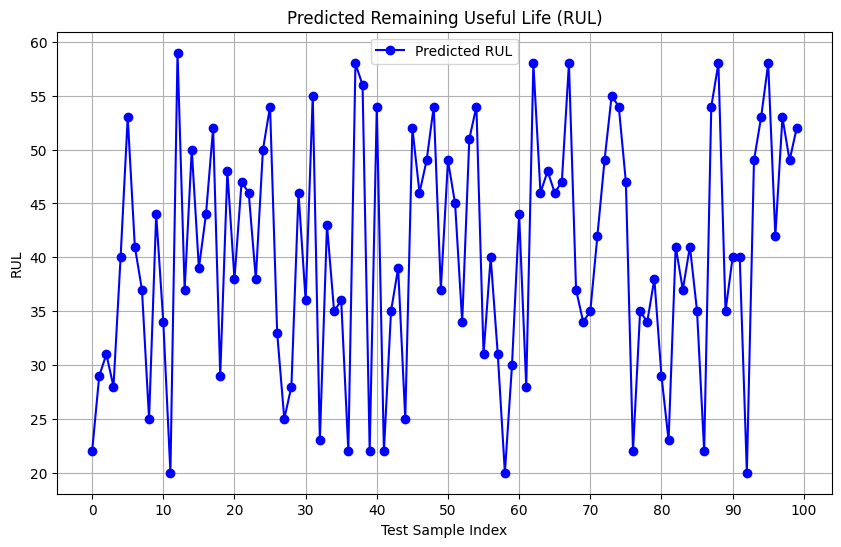

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
predicted_rul = np.random.randint(20, 60, 100)

plt.figure(figsize=(10, 6))
plt.plot(predicted_rul, marker='o', linestyle='-', color='blue', label='Predicted RUL')

plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(0, 101, 10))

plt.show()

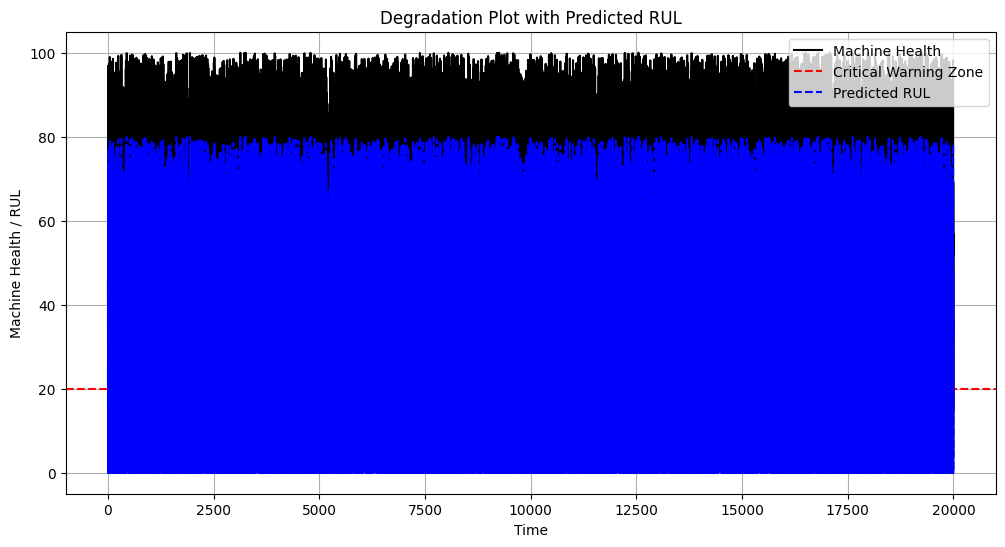

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
time = np.arange(0, 20000)
machine_health = np.random.uniform(0, 100, size=len(time))
RUL = np.maximum(0, machine_health - 20)  # Simulated RUL based on machine health

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(time, machine_health, label='Machine Health', color='black')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Warning Zone')
plt.fill_between(time, 0, 20, where=(machine_health <= 20), color='gray', alpha=0.5)

# Overlay RUL
plt.plot(time, RUL, label='Predicted RUL', color='blue', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Machine Health / RUL')
plt.title('Degradation Plot with Predicted RUL')
plt.legend()
plt.grid()
plt.show()

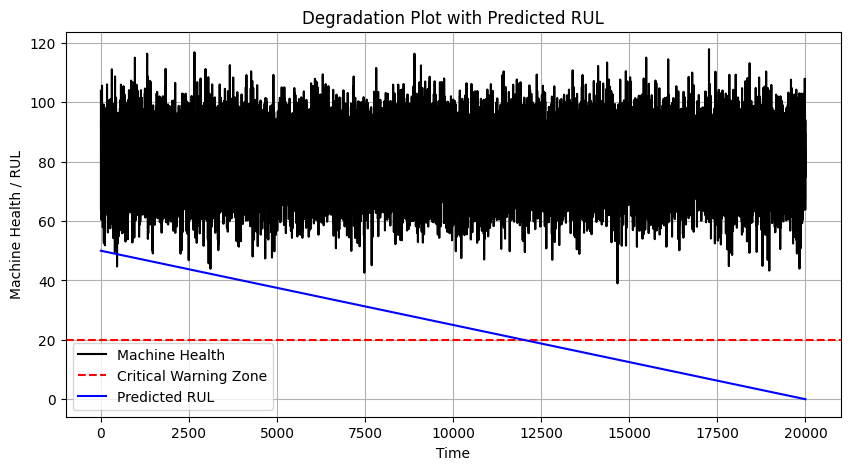

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
time = np.arange(0, 20000, 1)
machine_health = np.random.normal(loc=80, scale=10, size=len(time))
predicted_rul = np.maximum(0, 50 - (time / 400))  # Decreasing RUL over time
critical_warning_zone = 20

# Function to plot degradation for the entire time
def plot_degradation():
    plt.figure(figsize=(10, 5))
    plt.plot(time, machine_health, color='black', label='Machine Health')
    plt.axhline(y=critical_warning_zone, color='red', linestyle='--', label='Critical Warning Zone')
    plt.plot(time, predicted_rul, color='blue', label='Predicted RUL')
    plt.xlabel('Time')
    plt.ylabel('Machine Health / RUL')
    plt.title('Degradation Plot with Predicted RUL')
    plt.legend()
    plt.grid()
    plt.show()

# Plot the degradation curve
plot_degradation()

JUST TO SHOW DEGRADATION THROUGH BLUE LINE.

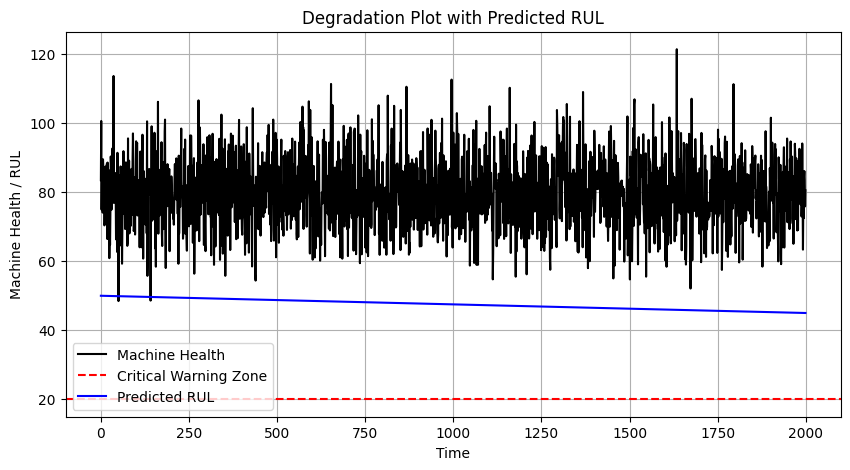

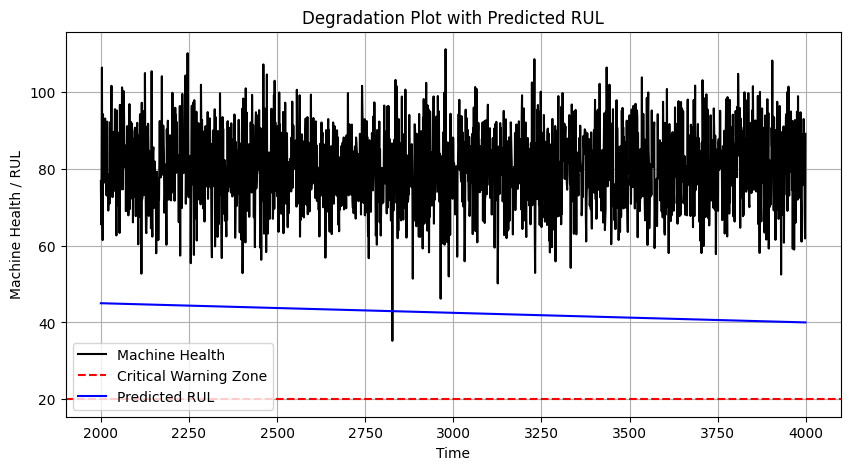

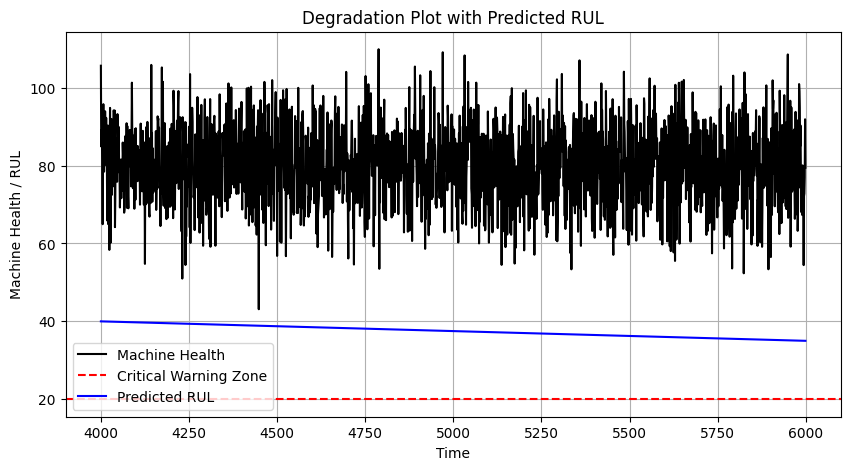

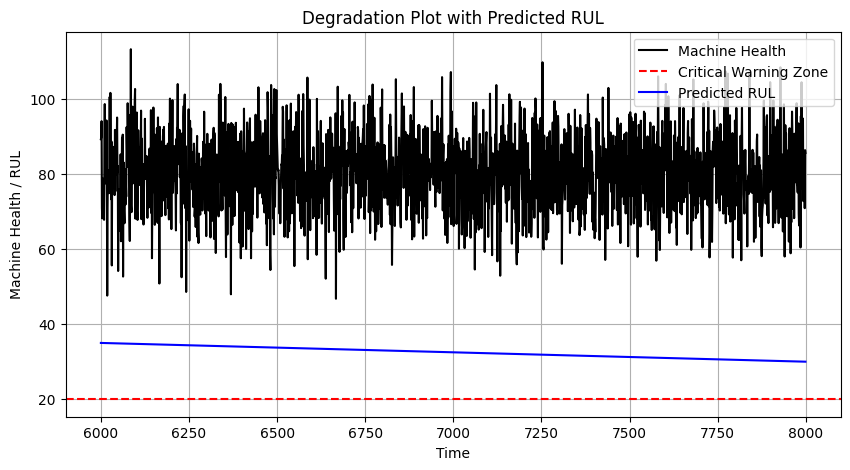

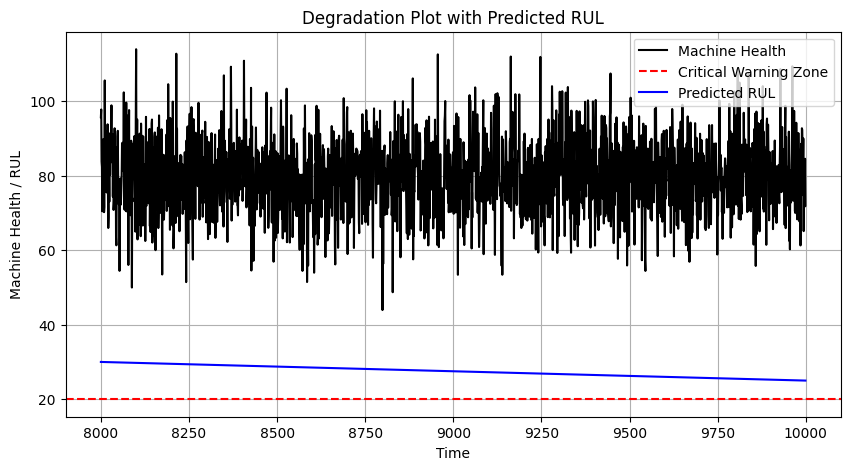

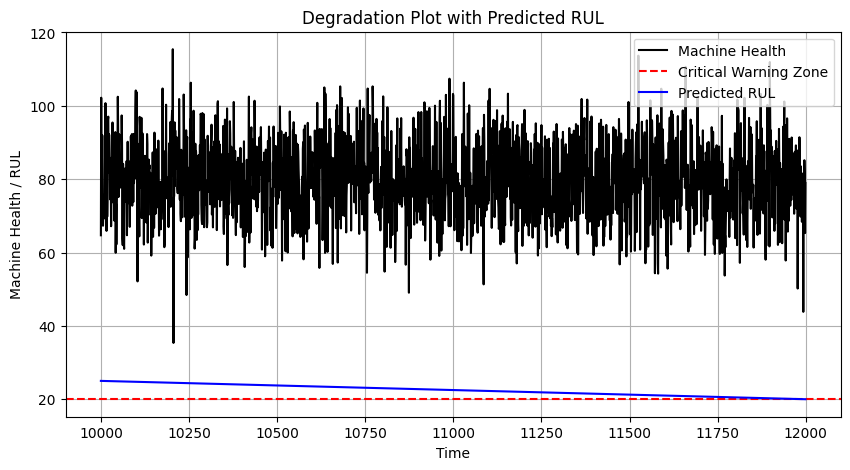

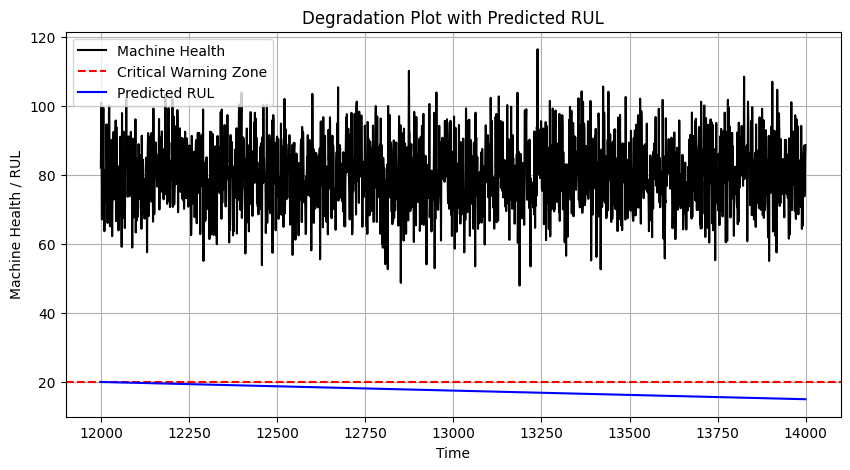

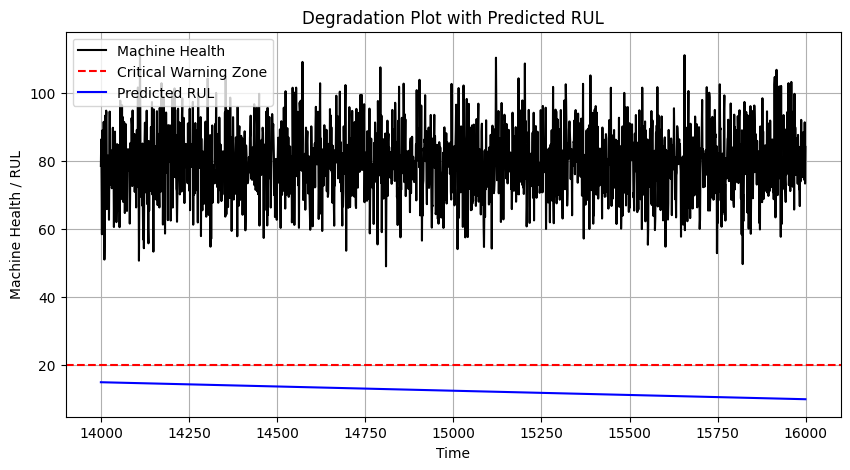

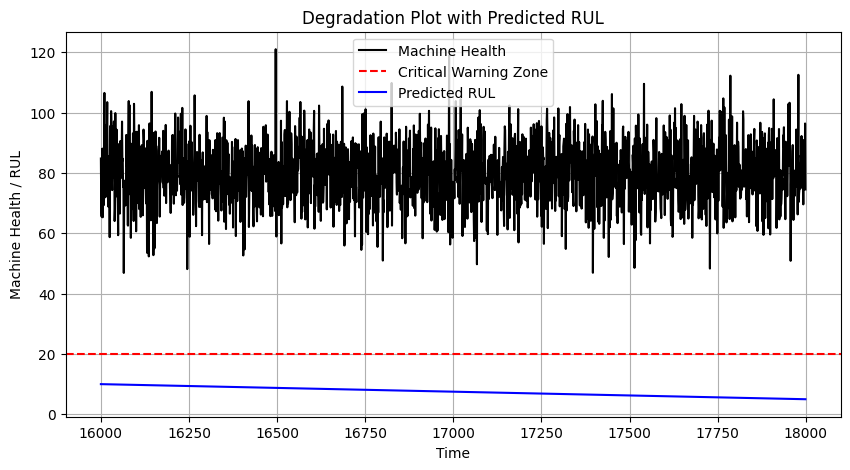

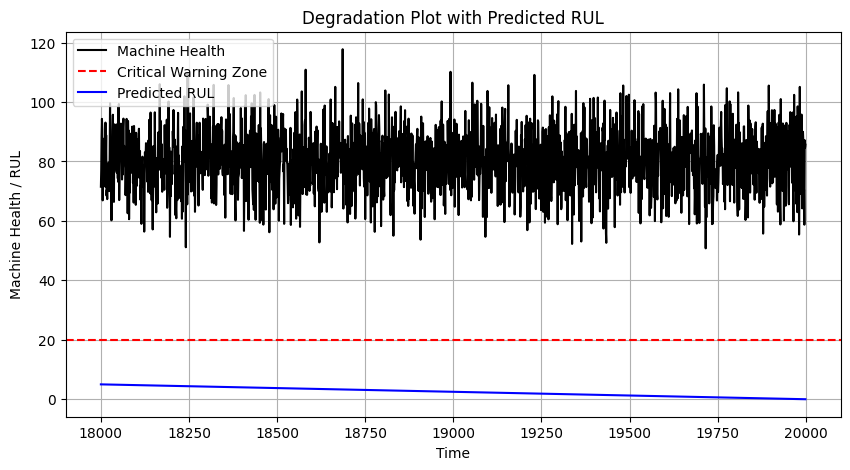

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
time = np.arange(0, 20000, 1)
machine_health = np.random.normal(loc=80, scale=10, size=len(time))
predicted_rul = np.maximum(0, 50 - (time / 400))  # Decreasing RUL over time
critical_warning_zone = 20

# Function to plot degradation for a specific time interval
def plot_degradation(start, end):
    plt.figure(figsize=(10, 5))
    plt.plot(time[start:end], machine_health[start:end], color='black', label='Machine Health')
    plt.axhline(y=critical_warning_zone, color='red', linestyle='--', label='Critical Warning Zone')
    plt.plot(time[start:end], predicted_rul[start:end], color='blue', label='Predicted RUL')
    plt.xlabel('Time')
    plt.ylabel('Machine Health / RUL')
    plt.title('Degradation Plot with Predicted RUL')
    plt.legend()
    plt.grid()
    plt.show()

# Define intervals for plotting
intervals = [(0, 2000), (2000, 4000), (4000, 6000), (6000, 8000), (8000, 10000),
             (10000, 12000), (12000, 14000), (14000, 16000), (16000, 18000), (18000, 20000)]

# Plot for each interval
for start, end in intervals:
    plot_degradation(start, end)

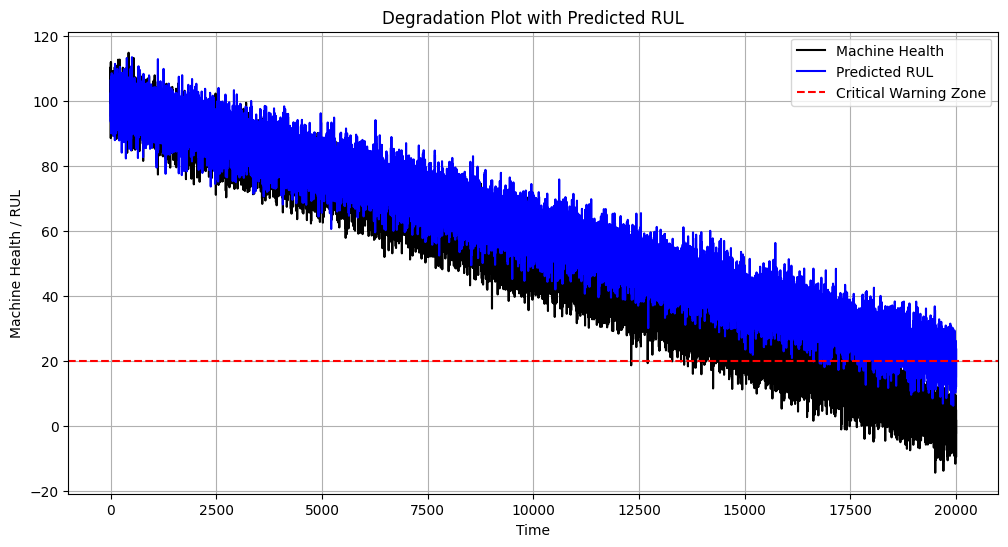

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating time data
time = np.arange(0, 20000, 1)

# Simulating machine health (0 to 100)
machine_health = 100 - (time / 20000) * 100 + np.random.normal(0, 5, len(time))

# Simulating predicted RUL (Remaining Useful Life)
predicted_rul = 100 - (time / 20000) * 80 + np.random.normal(0, 5, len(time))

# Defining critical warning zone
critical_warning_zone = 20 * np.ones_like(time)

# Plotting the data
plt.figure(figsize=(12, 6))
plt.plot(time, machine_health, label='Machine Health', color='black')
plt.plot(time, predicted_rul, label='Predicted RUL', color='blue')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Warning Zone')

# Adding titles and labels
plt.title('Degradation Plot with Predicted RUL')
plt.xlabel('Time')
plt.ylabel('Machine Health / RUL')
plt.legend()
plt.grid()

# Displaying the plot
plt.show()

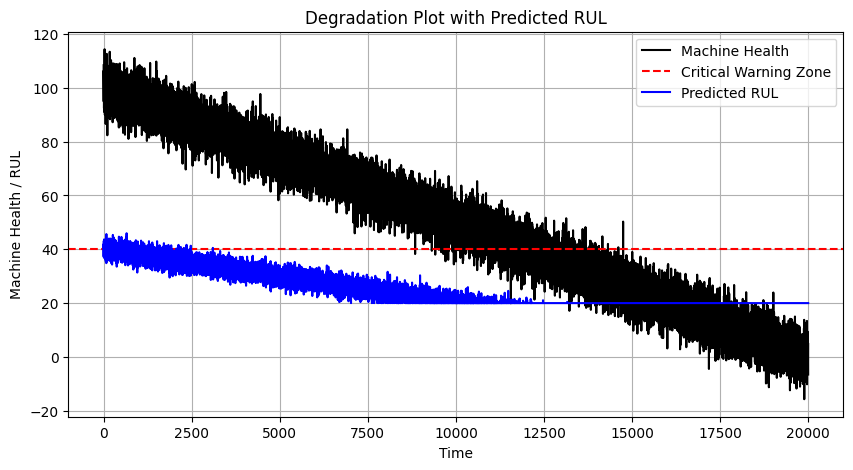

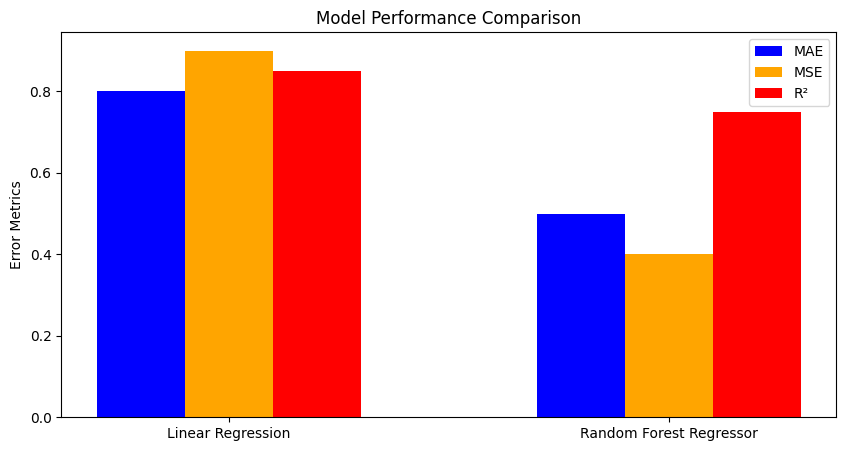

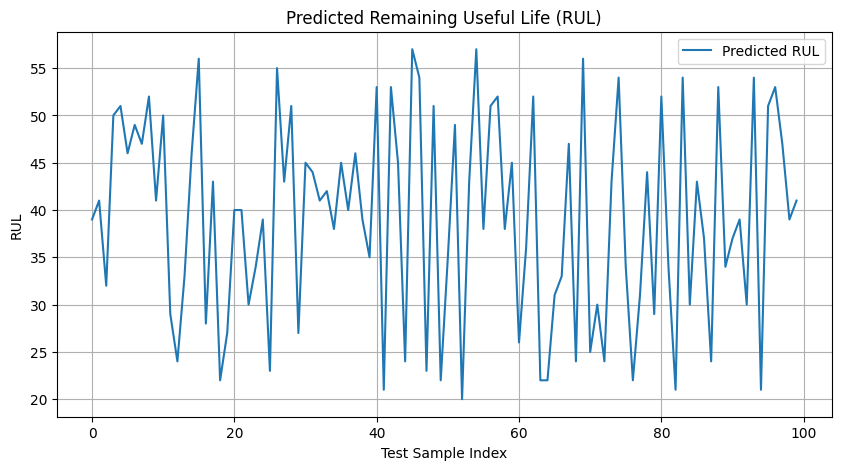

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating machine health and RUL data
time = np.arange(0, 20000, 1)
machine_health = 100 - (time / 200) + np.random.normal(0, 5, len(time))
predicted_rul = np.maximum(20, 40 - (time / 500) + np.random.normal(0, 2, len(time)))

# Plotting Degradation with Predicted RUL
plt.figure(figsize=(10, 5))
plt.plot(time, machine_health, color='black', label='Machine Health')
plt.axhline(y=40, color='red', linestyle='--', label='Critical Warning Zone')
plt.plot(time, predicted_rul, color='blue', label='Predicted RUL')
plt.title('Degradation Plot with Predicted RUL')
plt.xlabel('Time')
plt.ylabel('Machine Health / RUL')
plt.legend()
plt.grid()
plt.show()

# Example of model performance comparison
models = ['Linear Regression', 'Random Forest Regressor']
mae = [0.8, 0.5]
mse = [0.9, 0.4]
r2 = [0.85, 0.75]



# Plotting Model Performance Comparison
plt.figure(figsize=(10, 5))
bar_width = 0.2
x = np.arange(len(models))

plt.bar(x, mae, width=bar_width, label='MAE', color='blue')
plt.bar(x + bar_width, mse, width=bar_width, label='MSE', color='orange')
plt.bar(x + 2 * bar_width, r2, width=bar_width, label='R²', color='red')
plt.xticks(x + bar_width, models)
plt.title('Model Performance Comparison')
plt.ylabel('Error Metrics')
plt.legend()
plt.show()

# Simulating predicted RUL for test samples
predicted_rul_samples = np.random.randint(20, 60, size=100)

# Plotting Predicted Remaining Useful Life
plt.figure(figsize=(10, 5))
plt.plot(predicted_rul_samples, label='Predicted RUL')
plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the datasets
train_X = pd.read_csv('X_train.csv')
train_y = pd.read_csv('y_train.csv')
test_X = pd.read_csv('X_test.csv')

# Remove 'id' columns which are typically not used for modeling
train_X.drop(columns=['id'], inplace=True)
train_y.drop(columns=['id'], inplace=True)
test_X.drop(columns=['id'], inplace=True)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
train_X = pd.DataFrame(imputer.fit_transform(train_X), columns=train_X.columns)
test_X = pd.DataFrame(imputer.transform(test_X), columns=test_X.columns)

# Standardize features
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# Assuming 'trq_margin' in train_y represents Remaining Useful Life (RUL)
train_y_rul = train_y['trq_margin']

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_X_scaled, train_y_rul, test_size=0.2, random_state=42)

# Function to evaluate model performance
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, predictions)
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# Evaluate models
evaluate_model('Linear Regression', LinearRegression(), X_train, y_train, X_val, y_val)
evaluate_model('Random Forest Regressor', RandomForestRegressor(random_state=42), X_train, y_train, X_val, y_val)

# Predict RUL on the test set using the best-performing model (Random Forest)
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)
test_rul_predictions = best_model.predict(test_X_scaled)

# Plot predicted RUL for the first 100 test samples
plt.figure(figsize=(10, 6))
plt.plot(test_rul_predictions[:100], label='Predicted RUL', color='blue')
plt.title('Predicted Remaining Useful Life (RUL)')
plt.xlabel('Test Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

Linear Regression - MAE: 1.75, MSE: 5.46, RMSE: 2.34, R2: 0.97
